In [1]:
!pip install osmnx

/bin/bash: ligne 1: /home/mael/Bureau/Memoire/venv/bin/pip : ne peut exécuter : le fichier requis n'a pas été trouvé


# **Import library**

In [2]:
import networkx as nx
from  networkx.algorithms import approximation as approx
import networkx.algorithms.connectivity as conn
import random
import pandas as pd
import time
import math
import gc
import sys
from collections import deque, defaultdict
import copy
import networkx as nx
import osmnx as ox
from networkx.algorithms.flow.capacityscaling import capacity_scaling
from networkx.algorithms.bridges import bridges
from networkx.classes.function import nodes
from  networkx.algorithms import approximation as approx
import networkx.algorithms.connectivity as conn
import numpy as np
import matplotlib.pyplot as plt
from networkx.algorithms.flow import edmonds_karp
from networkx.algorithms.flow import preflow_push
from networkx.algorithms.flow import dinitz_alg
from networkx.algorithms.flow import dinitz

# **Save parameters of graph**

In [ ]:
res = {
"Ville": "place",
"Noeuds (n)":" n,",
"Aretes (m)": "m",
"Densite": "density",
"Degre moyen": "degree_avg",
"Degre min": "degree_min",
"Degre max": "degree_max",
"Composantes connexes": "num_components",
"Diametre": "diameter",
"Clustering moyen": "clustering_avg",
"Centralite degre (moy)": "degree_centrality",
"Centralite intermediarite (moy)": "betweenness_avg",
"Centralite proximite (moy)": "closeness",
"Longueur totale (m)": "edge_length_total",
"Longueur moyenne (m)": "edge_length_avg"
        }


In [ ]:
#path = "/home/mael/Téléchargements/Mael/Memoire/"
cities = ["bruges_Belgique.graphml",
          "Venise_Italie.graphml",
          "Oxford_Angleterre.graphml",
          "Dakar_Senegal.graphml", "Kigali_Rwanda.graphml",
          "Mons_Belgique.graphml", "marseille_France.graphml",
         "Johor_Bahru_Malaysia.graphml"]

city = [city for city in cities]
cities_without_extension = [city.split('/')[-1].split('.')[0] for city in cities]
graphs = open_graphml(city)

In [ ]:
def analyze_city_graph(cities, graph):
    """
    Analyse une collection de graphes routiers OSMnx et calcule leurs métriques principales.

    Args:
        cities: Liste des noms de villes associés aux graphes.
        graph: Liste des graphes OSMnx à analyser.

    Returns:
        Un DataFrame pandas contenant une ligne de métriques par ville.
    """
    result = []
    for place, G in zip(cities, graph):
        copy_dict = res.copy()

        # Certaines métriques sont calculées sur une version non orientée et simplifiée du graphe.
        G_undirected = G.to_undirected()
        G_simple = nx.Graph(G_undirected)

        n = G.number_of_nodes()
        m = G.number_of_edges()

        degrees = [deg for node, deg in G.degree()]

        degree_avg = np.mean(degrees)
        degree_min = np.min(degrees)
        degree_max = np.max(degrees)

        density = nx.density(G)

        num_components = nx.number_connected_components(G_simple)

        if num_components == 1:
            diameter = nx.diameter(G_simple)
        else:
            diameter = None

        clustering_avg = nx.average_clustering(G_simple)
        degree_centrality = np.mean(list(nx.degree_centrality(G_simple).values()))

        # On approxime la betweenness pour garder un temps de calcul raisonnable sur les grands graphes.
        betweenness = nx.betweenness_centrality(G_simple, k=min(500, n), normalized=True)
        betweenness_avg = np.mean(list(betweenness.values()))

        closeness = np.mean(list(nx.closeness_centrality(G_simple).values()))

        edge_lengths = [data.get("length", 0) for u, v, data in G.edges(data=True)]
        edge_length_total = np.sum(edge_lengths)
        edge_length_avg = np.mean(edge_lengths)
        copy_dict["ville"] = place
        print(copy_dict["ville"])
        copy_dict["Noeuds (n)"] = n
        copy_dict["Aretes (m)"] = m
        copy_dict["Degre moyen"] = degree_avg
        copy_dict["Degre min"] = degree_min
        copy_dict["Degre max"] = degree_max
        copy_dict["Densite"] = density
        copy_dict["Composantes connexes"] = num_components
        copy_dict["Diametre"] = diameter
        copy_dict["Clustering moyen"] = clustering_avg
        copy_dict["Centralite degre (moy)"] = degree_centrality
        copy_dict["Centralite intermediarite (moy)"] = betweenness_avg
        copy_dict["Centralite proximite (moy)"] = closeness
        copy_dict["Longueur totale (m)"] = edge_length_total
        copy_dict["Longueur moyenne (m)"] = edge_length_avg
        result.append(copy_dict)

    df = pd.DataFrame(result)
    return df



df_results = analyze_city_graph(cities_without_extension, graphs)
print("\nRésumé des métriques :")
print(df_results)

# Export CSV pour Overleaf
df_results.to_csv("graph_metrics_annexe.csv", index=False)

print("\nFichier 'graph_metrics_annexe.csv' généré.")


# **Build and plot the graph**

In [3]:
def download(places):
    """
    Télécharge les graphes routiers OSMnx pour une liste de lieux.

    Args:
        places: Liste des lieux à télécharger.

    Returns:
        Une liste de graphes OSMnx simplifiés de type `drive`.
    """
    return [ox.graph_from_place(place, network_type="drive", simplify=True, retain_all=False) for place in places]


In [ ]:
def open_graphml(filenames):
    """
    Charge plusieurs graphes enregistrés au format GraphML.

    Args:
        filenames: Liste des chemins de fichiers GraphML.

    Returns:
        Une liste de graphes NetworkX/OSMnx chargés depuis le disque.
    """
    return [ox.load_graphml(filename) for filename in filenames]


In [ ]:
def plot_graph(graphs, places):
    """
    Affiche une visualisation OSMnx pour chaque graphe fourni.

    Args:
        graphs: Liste des graphes à afficher.
        places: Liste des titres à associer à chaque graphe.

    Returns:
        Une liste de couples `(fig, ax)` générés pour chaque graphe.
    """
    plots = []
    for G, place in zip(graphs, places):
        fig, ax = ox.plot_graph(
            G,
            node_size=10,
            bgcolor="white",
            node_color="black",
            edge_color="green",
            edge_linewidth=0.5,
            show=False,
            close=False,
        )
        ax.set_title(place)
        plots.append((fig, ax))
        plt.show()
    return plots


In [ ]:
def save_graphs(graphs, places):
    """
    Enregistre une liste de graphes au format GraphML.

    Args:
        graphs: Liste des graphes à sauvegarder.
        places: Liste des noms de lieux utilisés pour générer les noms de fichiers.
    """
    for G, place in zip(graphs, places):
        filename = f"{place.replace(',', '').replace(' ', '_')}.graphml"
        ox.save_graphml(G, filename)


In [ ]:
def save_graphs_as_png(graphs, places):
    """
    Exporte une image PNG pour chaque graphe fourni.

    Args:
        graphs: Liste des graphes à représenter.
        places: Liste des noms utilisés pour les titres et fichiers de sortie.
    """
    for G, place in zip(graphs, places):
        # Chaque figure est créée séparément pour éviter les réécritures de rendu.
        fig, ax = ox.plot_graph(
            G,
            node_size=10,
            bgcolor="white",
            node_color="black",
            edge_color="green",
            edge_linewidth=0.5,
            show=False,
            close=False,
        )
        ax.set_title(place)
        filename = f"{place.replace(',', '').replace(' ', '_')}.png"
        fig.savefig(filename, dpi=300)
        plt.close(fig)
        print(f"Saved {filename}")


In [4]:
places = [
    "bruges, Belgique",
    #"Jakarta, Indonesia",
    "Venise, Italie",
    #"tokyo, japan",
    #"barcelone, espagne",
    #"Oxford, Angleterre",
    #"Dakar, Senegal",
    #"new-york , usa",
    #"Kigali, Rwanda",
    #"Nimy, Belgique",
    #"Gosselies, Belgique",
    #"Obourg, Belgique"
    ]
result = download(places)
#save_graphs(result,places)
#save_graphs_as_png(result, places)
#plot_graph(result,places)
#result

In [ ]:
def save_graphs(graphs, places):
    """
    Enregistre une liste de graphes au format GraphML.

    Args:
        graphs: Liste des graphes à sauvegarder.
        places: Liste des noms de lieux utilisés pour générer les noms de fichiers.
    """
    for G, place in zip(graphs, places):
        filename = f"{place.replace(',', '').replace(' ', '_')}.graphml"
        ox.save_graphml(G, filename)


In [ ]:
save_graphs(result,places)

In [ ]:
for place, G in zip(places,result):
  print(place,ox.basic_stats(G))
for place, G in zip(places,result):
  print(place, nx.density(G))

Nimy, Belgique {'n': 149, 'm': 332, 'k_avg': 4.456375838926174, 'edge_length_total': 43718.31247660395, 'edge_length_avg': 131.68166408615647, 'streets_per_node_avg': 2.7114093959731544, 'streets_per_node_counts': {0: 0, 1: 27, 2: 3, 3: 106, 4: 12, 5: 1}, 'streets_per_node_proportions': {0: 0.0, 1: 0.18120805369127516, 2: 0.020134228187919462, 3: 0.7114093959731543, 4: 0.08053691275167785, 5: 0.006711409395973154}, 'intersection_count': 122, 'street_length_total': 24576.48509337836, 'street_segment_count': 192, 'street_length_avg': 128.00252652801228, 'circuity_avg': 1.0995052869853161, 'self_loop_proportion': 0.005208333333333333}
Gosselies, Belgique {'n': 448, 'm': 909, 'k_avg': 4.058035714285714, 'edge_length_total': 118576.80450328025, 'edge_length_avg': 130.44752970657893, 'streets_per_node_avg': 2.857142857142857, 'streets_per_node_counts': {0: 0, 1: 54, 2: 4, 3: 344, 4: 44, 5: 2}, 'streets_per_node_proportions': {0: 0.0, 1: 0.12053571428571429, 2: 0.008928571428571428, 3: 0.7678

In [ ]:
def get_info_on_edges(graphs, places):
    """
    Récupère un extrait des arêtes de chaque graphe avec leurs attributs.

    Args:
        graphs: Liste des graphes à inspecter.
        places: Liste des noms associés aux graphes.

    Returns:
        Une liste de tuples `(lieu, arêtes)` contenant les trois premières arêtes de chaque graphe.
    """
    res = []
    for place, G in zip(places, graphs):
        res.append((place, list(G.edges(data=True))[:3]))
    return res

info = get_info_on_edges(result,places)
info


[('Nimy, Belgique',
  [(9094067,
    1366957524,
    {'osmid': 122291704,
     'highway': 'motorway_link',
     'lanes': '1',
     'oneway': True,
     'reversed': False,
     'length': np.float64(21.944826974750363)}),
   (9094067,
    380978184,
    {'osmid': 657839095,
     'highway': 'primary',
     'lanes': '1',
     'maxspeed': '50',
     'name': 'Rue des Viaducs',
     'oneway': True,
     'ref': 'N6',
     'reversed': False,
     'length': np.float64(107.17435858268021),
     'geometry': <LINESTRING (3.954 50.483, 3.953 50.483, 3.953 50.483)>}),
   (204902686,
    1234917900,
    {'osmid': 19716377,
     'highway': 'motorway_link',
     'lanes': '1',
     'maxspeed': '70',
     'oneway': True,
     'reversed': False,
     'length': np.float64(576.8170391833252),
     'geometry': <LINESTRING (3.955 50.484, 3.955 50.485, 3.955 50.485, 3.954 50.485, 3.954 5...>})]),
 ('Gosselies, Belgique',
  [(29685663,
    6520605458,
    {'osmid': 23034174,
     'highway': 'motorway_link',
    

# **Remove all nodes of degree 1, to improve connexity**

In [5]:
def remove_nodes_of_degree_one(G, place):
    """
    Supprime les nœuds de degré 1 dans un graphe non orienté.

    Args:
        G: Le graphe à nettoyer.
        place: Le nom associé au graphe.

    Returns:
        Un tuple (graphe nettoyé, résumé des suppressions).
    """
    initial_node_count = G.number_of_nodes()
    G_undirected = G.to_undirected() if G.is_directed() else G.copy()

    nodes_to_remove = [node for node, degree in dict(G_undirected.degree()).items() if degree == 1]
    G_undirected.remove_nodes_from(nodes_to_remove)

    final_node_count = G_undirected.number_of_nodes()
    removed_count = len(nodes_to_remove)

    summary = {
        "place": place,
        "initial_node_count": initial_node_count,
        "removed_count": removed_count,
        "final_node_count": final_node_count,
    }

    return G_undirected, summary


def remove_nodes_of_degree_one_k(graphs, places, k):
    """
    Répète la suppression des nœuds de degré 1 k fois pour chaque graphe.
    Le graphe de sortie de l'itération i devient le graphe d'entrée de l'itération i+1.

    Args:
        graphs: Liste des graphes à nettoyer.
        places: Liste des noms associés aux graphes.
        k: Nombre d'itérations.

    Returns:
        Un dictionnaire {place: (graphe_final, liste_des_résumés_par_itération)}.
    """
    results = {}

    for G, place in zip(graphs, places):
        current_graph = G
        all_summaries = []

        for iteration in range(k):
            current_graph, summary = remove_nodes_of_degree_one(current_graph, place)
            summary["iteration"] = iteration + 1
            all_summaries.append(summary)

            # Arrêt anticipé si plus aucun nœud de degré 1
            if summary["removed_count"] == 0:
                print(f"[{place}] Arrêt anticipé à l'itération {iteration + 1} : aucun nœud de degré 1 restant.")
                break

        results[place] = (current_graph, all_summaries)

    return results

In [7]:
results = remove_nodes_of_degree_one_k(result, places, k=9)

for place, (final_graph, summaries) in results.items():
    print(f"\n=== {place} ===")
    for s in summaries:
        print(f"  Itération {s['iteration']} : {s['initial_node_count']} → {s['final_node_count']} noeuds ({s['removed_count']} supprimés)")

[bruges, Belgique] Arrêt anticipé à l'itération 7 : aucun nœud de degré 1 restant.

=== bruges, Belgique ===
  Itération 1 : 4440 → 3655 noeuds (785 supprimés)
  Itération 2 : 3655 → 3536 noeuds (119 supprimés)
  Itération 3 : 3536 → 3490 noeuds (46 supprimés)
  Itération 4 : 3490 → 3474 noeuds (16 supprimés)
  Itération 5 : 3474 → 3470 noeuds (4 supprimés)
  Itération 6 : 3470 → 3469 noeuds (1 supprimés)
  Itération 7 : 3469 → 3469 noeuds (0 supprimés)

=== Venise, Italie ===
  Itération 1 : 6273 → 4887 noeuds (1386 supprimés)
  Itération 2 : 4887 → 4706 noeuds (181 supprimés)
  Itération 3 : 4706 → 4637 noeuds (69 supprimés)
  Itération 4 : 4637 → 4608 noeuds (29 supprimés)
  Itération 5 : 4608 → 4592 noeuds (16 supprimés)
  Itération 6 : 4592 → 4582 noeuds (10 supprimés)
  Itération 7 : 4582 → 4575 noeuds (7 supprimés)
  Itération 8 : 4575 → 4572 noeuds (3 supprimés)
  Itération 9 : 4572 → 4571 noeuds (1 supprimés)


In [8]:
graph_results ={place:graph for place, (graph, _) in results.items()}
place  = []
Graph = []
for elem,G in graph_results.items():
  print(elem,G.number_of_nodes())
  place.append(elem)
  Graph.append(G)
#plot_graph(Graph,place)




bruges, Belgique 3469
Venise, Italie 4571


In [9]:
graph_results

{'bruges, Belgique': <networkx.classes.multigraph.MultiGraph at 0x79ba249802c0>,
 'Venise, Italie': <networkx.classes.multigraph.MultiGraph at 0x79ba249a43e0>}

In [10]:
#Trouver la plus grande composante connexe
def find_largest_connected_component(graph):
    """
    Extrait la plus grande composante connexe de chaque graphe si nécessaire.

    Args:
        graph: Dictionnaire produit par `remove_nodes_of_degree_one`.

    Returns:
        Un dictionnaire associant chaque lieu au graphe connexe retenu et à sa connectivité par arêtes.
    """
    res = {}
    #datas = [data for data in graph.keys()]
    for place, G_ox_undirected in graph.items():
        if not nx.is_connected(G_ox_undirected):
            largest_cc_nodes = max(nx.connected_components(G_ox_undirected), key=len)
            H_ox = G_ox_undirected.subgraph(largest_cc_nodes).copy()
            res[place] = H_ox, conn.edge_connectivity(H_ox)
        else:
            H_ox = G_ox_undirected.copy()
            res[place] = H_ox, conn.edge_connectivity(H_ox)
    return res


In [11]:
largest_component = find_largest_connected_component(graph_results)
largest_component

{'bruges, Belgique': (<networkx.classes.multigraph.MultiGraph at 0x79ba249a6900>,
  1),
 'Venise, Italie': (<networkx.classes.multigraph.MultiGraph at 0x79ba249a71a0>,
  1)}

In [12]:
for place, G in largest_component.items():
  print(place, G[0])

bruges, Belgique MultiGraph with 3469 nodes and 5107 edges
Venise, Italie MultiGraph with 4571 nodes and 6479 edges


#***Selecting the source and sink using the northernmost node as the source and the southernmost node as the sink***

In [13]:
def connect_north_south_extremes(G, top_k=5):
    """
    Relie le nœud le plus au nord et celui le plus au sud aux nœuds centraux les plus pertinents.

    La sélection priorise d'abord la betweenness centrality, puis la distance topologique.

    Args:
        G: Graphe à modifier.
        top_k: Nombre de connexions à ajouter pour chaque extrémité.

    Returns:
        Un tuple contenant le graphe modifié, le nœud nord et le nœud sud.
    """
    speed = [(20, 1), (30, 1), (50, 2), (50, 1), (70, 2), (90, 2), (90, 3), (120, 2), (120, 3)]

    north_node = max(G.nodes, key=lambda n: G.nodes[n]['y'])
    south_node = min(G.nodes, key=lambda n: G.nodes[n]['y'])

    if isinstance(G, (nx.MultiDiGraph, nx.MultiGraph)):
        G_simple = nx.Graph(G)
    else:
        G_simple = G

    bc = nx.betweenness_centrality(G_simple, weight=None)
    bc.pop(north_node, None)
    bc.pop(south_node, None)

    dist_north = nx.single_source_shortest_path_length(G_simple, north_node)
    dist_south = nx.single_source_shortest_path_length(G_simple, south_node)

    def select_nodes(distances, excluded_nodes):
        """
        Sélectionne les meilleurs candidats selon la centralité puis la distance.

        Args:
            distances: Distances topologiques depuis le nœud extrême courant.
            excluded_nodes: Ensemble de nœuds à ignorer.

        Returns:
            La liste des nœuds retenus pour ajouter de nouvelles arêtes.
        """
        candidates = []

        for node, centrality in bc.items():
            if node in excluded_nodes:
                continue

            if node not in distances:
                continue

            candidates.append((node, centrality, distances[node]))

        candidates.sort(key=lambda x: (-x[1], -x[2]))
        selected = [node for node, _, _ in candidates[:top_k]]
        return selected

    selected_north = select_nodes(dist_north, excluded_nodes=set())
    selected_south = select_nodes(dist_south, excluded_nodes=set(selected_north))

    # Les nouvelles arêtes reçoivent des paramètres de vitesse et de voies simulés.
    for node in selected_north:
        random.shuffle(speed)
        val = random.choice(speed)
        G.add_edge(north_node, node, maxspeed=val[0], lane=val[1])

    for node in selected_south:
        random.shuffle(speed)
        val = random.choice(speed)
        G.add_edge(south_node, node, maxspeed=val[0], lane=val[1])

    return G, north_node, south_node


In [14]:
def compute_source_sink(graphs_dict, k):
    """
    Calcule les couples source/puits à partir des extrémités nord et sud de chaque graphe.

    Args:
        graphs_dict: Dictionnaire de graphes par lieu.
        k: Nombre de connexions à ajouter pour chaque extrémité.

    Returns:
        Un tuple contenant les graphes modifiés et les couples `(source, sink)` par lieu.
    """
    result_graph = {}
    result_source_sink = {}
    for place, G in graphs_dict.items():
        G, north_node, south_node = connect_north_south_extremes(G[0], k)
        result_graph[place] = G
        result_source_sink[place] = (north_node, south_node)

    return result_graph, result_source_sink


In [15]:
result_graph, result_source_sink = compute_source_sink(largest_component,4)

#***Selection of the source and sink by using maximum degree method***

In [ ]:
def max_distance_high_degre_pairs_fast(G, degree, w_degree=0.6, w_dist=0.4):
    """
    Recherche les paires de nœuds de degré élevé les plus éloignées dans le graphe,
    en combinant les deux objectifs (degré et distance) via une somme pondérée normalisée.

    Score(u, v) = w_degree * (deg(u) + deg(v)) / max_deg_sum
                + w_dist   * dist(u, v)         / max_dist

    La paire retenue est celle qui maximise ce score composite.

    Args:
        G        : Graphe dans lequel calculer les distances.
        degree   : Dictionnaire {noeud: degré}.
        w_degree : Poids accordé au degré (entre 0 et 1). Défaut : 0.6.
        w_dist   : Poids accordé à la distance (entre 0 et 1). Défaut : 0.4.

    Returns:
        Un dictionnaire {(u, v): score} pour la paire optimale.
    """
    valid_nodes = [n for n, d in degree.items() if d >= 3]

    # Calcul des bornes pour la normalisation
    max_deg_sum = max((degree[u] + degree[v])
                      for u in valid_nodes for v in valid_nodes if u != v)

    # Première passe : collecter toutes les distances pour connaître max_dist
    raw = []  # (u, v, deg_sum, dist)
    for u in valid_nodes:
        lengths = nx.single_source_shortest_path_length(G, u)
        for v in valid_nodes:
            if u >= v:          # éviter les doublons et la diagonale
                continue
            if v in lengths:
                raw.append((u, v, degree[u] + degree[v], lengths[v]))

    if not raw:
        return {}

    max_dist = max(r[3] for r in raw)
    if max_dist == 0:
        max_dist = 1  # sécurité division par zéro

    # Seconde passe : calcul du score composite et sélection du meilleur
    best_score = -1.0
    result = {}
    for u, v, deg_sum, dist in raw:
        score = (w_degree * deg_sum / max_deg_sum
               + w_dist   * dist    / max_dist)
        if score > best_score:
            best_score = score
            result = {(u, v): score}

    return result


In [ ]:
def get_nodes_sorted_by_degree(graphs_dict):
    """
    Trie les nœuds par degré puis retient les paires les plus éloignées pour chaque graphe.

    Args:
        graphs_dict: Dictionnaire de graphes par lieu.

    Returns:
        Un dictionnaire associant chaque lieu aux paires de nœuds sélectionnées.
    """
    all_sorted_nodes = {}
    for place, graph in graphs_dict.items():
        degrees = dict(graph.degree())
        sorted_nodes = dict(sorted(degrees.items(), key=lambda item: item[1], reverse=True))
        far_degrees = max_distance_high_degre_pairs_fast(graph, sorted_nodes)

        all_sorted_nodes[place] = far_degrees
    return all_sorted_nodes

# Example usage with your 'result' variable (which contains a list of graphs)
sorted_nodes_list = get_nodes_sorted_by_degree(add_capacity)
for place, node in sorted_nodes_list.items():
  print(f"Graph {place} nodes sorted by degree (descending): {list(node.items())[:10]} (showing top 10)")


Graph Nimy, Belgique nodes sorted by degree (descending): [((1199868946, 1113248370), 17), ((1113248370, 1199868946), 17)] (showing top 10)
Graph Gosselies, Belgique nodes sorted by degree (descending): [((1375096085, 1135604304), 27), ((1135604304, 1375096085), 27)] (showing top 10)
Graph Obourg, Belgique nodes sorted by degree (descending): [((4062169297, 417325191), 9), ((286689134, 388301561), 9), ((5431747345, 388301561), 9), ((5431747345, 5434139328), 9), ((388301561, 286689134), 9), ((388301561, 5431747345), 9), ((388301561, 417628960), 9), ((388301561, 417325191), 9), ((1587503273, 417325191), 9), ((5434139328, 5431747345), 9)] (showing top 10)


In [ ]:
souce_sink = get_nodes_sorted_by_degree(add_capacity)
tuples_nimy, j= list(souce_sink['Nimy, Belgique'].keys())[0]
print(tuples_nimy,j)


1199868946 1113248370


#***Selection of the source and sink by using betweenness connected method***

In [ ]:
def max_distance_high_betweenness_pairs_fast(G, betweenness, w_between=0.6, w_dist=0.4):
    """
    Recherche les paires de nœuds à betweenness positive les plus éloignées,
    en combinant les deux objectifs via une somme pondérée normalisée.

    Score(u, v) = w_between * (bc(u) + bc(v)) / max_bc_sum
                + w_dist    * dist(u, v)        / max_dist

    Args:
        G          : Graphe dans lequel calculer les distances.
        betweenness: Dictionnaire {noeud: centralité}.
        w_between  : Poids accordé à la betweenness (entre 0 et 1). Défaut : 0.6.
        w_dist     : Poids accordé à la distance (entre 0 et 1). Défaut : 0.4.

    Returns:
        Un dictionnaire {(u, v): score} pour la paire optimale.
    """
    valid_nodes = [n for n, bc in betweenness.items() if bc > 0]

    # Borne supérieure de la somme de betweenness pour la normalisation
    max_bc_sum = max((betweenness[u] + betweenness[v])
                     for u in valid_nodes for v in valid_nodes if u != v)
    if max_bc_sum == 0:
        max_bc_sum = 1  # sécurité division par zéro

    # Première passe : collecte des distances
    raw = []  # (u, v, bc_sum, dist)
    for u in valid_nodes:
        lengths = nx.single_source_shortest_path_length(G, u)
        for v in valid_nodes:
            if u >= v:
                continue
            if v in lengths:
                raw.append((u, v, betweenness[u] + betweenness[v], lengths[v]))

    if not raw:
        return {}

    max_dist = max(r[3] for r in raw)
    if max_dist == 0:
        max_dist = 1

    # Seconde passe : score composite
    best_score = -1.0
    result = {}
    for u, v, bc_sum, dist in raw:
        score = (w_between * bc_sum / max_bc_sum
               + w_dist    * dist   / max_dist)
        if score > best_score:
            best_score = score
            result = {(u, v): score}

    return result


In [ ]:
def get_nodes_sorted_by_betweenness_centrality(graphs_dict):
    """
    Trie les nœuds par betweenness centrality puis retient les paires les plus éloignées.

    Args:
        graphs_dict: Dictionnaire de graphes par lieu.

    Returns:
        Un dictionnaire associant chaque lieu aux paires de nœuds sélectionnées.
    """
    all_sorted_nodes = {}
    for place, graph in graphs_dict.items():
        d = nx.betweenness_centrality(graph)
        sorted_dict = dict(sorted(d.items(), key=lambda item: item[1], reverse=True))
        far_degrees = max_distance_high_betweenness_pairs_fast(graph, sorted_dict)

        all_sorted_nodes[place] = far_degrees
    return all_sorted_nodes

# Example usage with your 'result' variable (which contains a list of graphs)
sorted_nodes_list = get_nodes_sorted_by_betweenness_centrality(add_capacity)
for place, node in sorted_nodes_list.items():
  print(f"Graph {place} : {list(node.items())[:10]}")


Graph Nimy, Belgique : [((221049023, 443056925), 0.6222222222222222)]
Graph Gosselies, Belgique : [((829531519, 8771967355), 0.6137931034482759)]
Graph Obourg, Belgique : [((418791779, 1773947473), 0.64)]


In [ ]:
souce_sink = get_nodes_sorted_by_degree(add_capacity)
tuples_nimy, j= list(souce_sink['Nimy, Belgique'].keys())[0]
print(tuples_nimy,j)


(1193224677,
 1194593999,
 {(1193224677, 1194593999): 5, (1194593999, 1193224677): 5})

# **Compute capacity of each edge**

In [16]:
#Compute capacity for each edge
def compute_capacity(graph):
    """
    Calcule une capacité théorique pour chaque arête à partir du nombre de voies et de la vitesse.

    Args:
        graph: Dictionnaire de graphes multi-arêtes par lieu.

    Returns:
        Le même dictionnaire de graphes enrichi avec l'attribut `capacity` sur chaque arête.
    """
    result = {}
    for place, G in graph.items():
        for u, v, k, data in G.edges(keys=True, data=True):
            lanes = data.get("lanes", 1)

            # Les attributs OSM peuvent être stockés sous plusieurs formats ; on les normalise ici.
            if isinstance(lanes, list):
                vals = []
                for l in lanes:
                    try:
                        vals.append(int(str(l).split()[0]))
                    except:
                        pass
                lanes = max(vals) if vals else 1

            elif isinstance(lanes, str):
                vals = []
                for part in lanes.split(";"):
                    try:
                        vals.append(int(part.strip()))
                    except:
                        pass
                lanes = max(vals) if vals else 1

            else:
                try:
                    lanes = int(lanes)
                except:
                    lanes = 1

            maxspeed = data.get("maxspeed", 50)

            if isinstance(maxspeed, list):
                vals = []
                for s in maxspeed:
                    try:
                        vals.append(int(str(s).split()[0]))
                    except:
                        pass
                maxspeed = max(vals) if vals else 50

            else:
                try:
                    maxspeed = int(str(maxspeed).split()[0])
                except:
                    maxspeed = 50

            capacity = 1800 * lanes * (maxspeed / 50)
            data["capacity"] = capacity

        result[place] = G
    return result


In [17]:
compute_capacity(result_graph)

{'bruges, Belgique': <networkx.classes.multigraph.MultiGraph at 0x79ba249a6900>,
 'Venise, Italie': <networkx.classes.multigraph.MultiGraph at 0x79ba249a71a0>}

In [18]:
#Attribute capacity at each edge
def add_capacity(graph):
    """
    Agrège les capacités d'un multigraphe dans un graphe simple non orienté.

    Args:
        graph: Dictionnaire de graphes contenant l'attribut `capacity` sur les arêtes.

    Returns:
        Un dictionnaire de graphes simples avec une capacité cumulée par arête.
    """
    result = {}
    for place, G_original in graph.items():
        H = nx.Graph()
        if hasattr(G_original, 'graph'):
            H.graph.update(G_original.graph)

        # Les multi-arêtes sont fusionnées en sommant leurs capacités.
        for u, v, key, data in G_original.edges(keys=True, data=True):
            cap = data.get("capacity", 0)
            if H.has_edge(u, v):
                H[u][v]["capacity"] += cap
            else:
                H.add_edge(u, v, capacity=cap)
        result[place] = H
    return result


In [19]:
graphs_with_capacity = compute_capacity(result_graph)
add_capacity = add_capacity(graphs_with_capacity)
add_capacity

{'bruges, Belgique': <networkx.classes.graph.Graph at 0x79ba37392b40>,
 'Venise, Italie': <networkx.classes.graph.Graph at 0x79ba249a6030>}

In [ ]:
for G in add_capacity.values():
  res = list(G.edges(data=True))[:3]
print(res)


[(286689120, 286689123, {'capacity': 1800.0}), (286689120, 388301728, {'capacity': 3600.0}), (286689120, 286689130, {'capacity': 1800.0})]


# **Run multiples algorithms for comparing execution time**

In [24]:
def get_graphs(graphs_dict, source_sink=None):
    """
    Associe à chaque graphe son couple source/puits pour les calculs de flot.

    Args:
        graphs_dict: Dictionnaire de graphes par lieu.
        source_sink: Dictionnaire {lieu: (source, sink)} produit par
            compute_source_sink (ou une méthode équivalente telle que
            get_nodes_sorted_by_degree).
            Si None, tente d'utiliser la variable globale result_source_sink
            pour des raisons de rétrocompatibilité — mais le passage explicite
            est fortement recommandé pour éviter d'utiliser des valeurs
            calculées par une méthode différente de celle souhaitée.

    Returns:
        Un dictionnaire `{lieu: (graphe, source, sink)}`.
    """
    if source_sink is None:
        # Repli sur la variable globale (rétrocompatibilité).
        # Lève une erreur explicite si elle n'est pas définie,
        # plutôt que de propager silencieusement de mauvaises valeurs.
        if 'result_source_sink' not in globals():
            raise ValueError(
                "Aucun dictionnaire source/sink fourni et result_source_sink "
                "n'est pas défini dans l'espace global. "
                "Passez source_sink explicitement, par exemple : "
                "get_graphs(add_capacity, source_sink=result_source_sink)."
            )
        source_sink = result_source_sink

    all_graphs = {}
    for place, graph in graphs_dict.items():
        source, sink = source_sink[place]
        all_graphs[place] = (graph, source, sink)
        if not nx.has_path(graph, source, sink):
            print(f"[{place}] Attention : aucun chemin entre source et sink.")
    return all_graphs

algos = {
    "Edmonds-Karp": nx.algorithms.flow.edmonds_karp,
    "Dinic": nx.algorithms.flow.dinitz,
    "Push-Relabel": nx.algorithms.flow.preflow_push
}


In [25]:
graphs = get_graphs(add_capacity, source_sink=result_source_sink)
graphs

{'bruges, Belgique': (<networkx.classes.graph.Graph at 0x79ba37392b40>,
  3390812463,
  82732110),
 'Venise, Italie': (<networkx.classes.graph.Graph at 0x79ba249a6030>,
  986220039,
  1100588297)}

In [20]:
def benchmark_maxflow(G, s, t, flow_func, runs=5, modified_edge=None):
    """
    Mesure le temps d'exécution moyen d'un algorithme de flot maximum.

    Args:
        G: Graphe NetworkX sur lequel exécuter l'algorithme.
        s: Nœud source.
        t: Nœud puits.
        flow_func: Fonction de calcul du flot maximum.
        runs: Nombre de répétitions pour la mesure.
        modified_edge: Tuple optionnel `(u, v, new_capacity)` pour tester une variation de capacité.

    Returns:
        Un dictionnaire contenant la valeur du flot et le temps moyen mesuré.
    """
    times = []
    flow_value = None

    for _ in range(runs):
        # Force la collecte des objets cycliques avant chaque run
        # pour éviter qu'un déclenchement du GC pendant le chronomètre
        # ne fausse la mesure de temps (NetworkX crée beaucoup d'objets
        # temporaires lors du calcul de flot).
        gc.collect()

        # Chaque exécution repart d'une copie propre du graphe.
        G_test = G.copy()

        if modified_edge is not None:
            u, v, new_capacity = modified_edge

            if not G_test.has_edge(u, v):
                raise ValueError("Arête inexistante dans le graphe")

            G_test[u][v]["capacity"] = new_capacity

        start = time.perf_counter()

        flow_value, _ = nx.maximum_flow(
            G_test,
            s,
            t,
            flow_func=flow_func,
            capacity="capacity"
        )

        end = time.perf_counter()

        times.append(end - start)

    return {
        "flow_value": flow_value,
        "mean_time": sum(times) / runs,
    }


In [21]:
def build_graph(graphs_dict):
    """
    Exécute les algorithmes de flot max sur chaque graphe et collecte les graphes résiduels.

    Args:
        graphs_dict: Dictionnaire `{lieu: (graphe, source, sink)}`.

    Returns:
        Un tuple `(résultats, graphes_résiduels)` indexé par lieu puis par algorithme.
    """
    all_results = {}
    residual_graph = {}
    for gname, (G, s, t) in graphs_dict.items():
        num_edges = G.number_of_edges()
        all_results[gname] = {}
        residual_graph[gname] = {}

        for aname, algo in algos.items():
            Residual = algo(G, s, t, capacity="capacity")
            res = benchmark_maxflow(G, s, t, algo, runs=7)
            all_results[gname][aname] = (res["mean_time"] / num_edges) * 1e6
            residual_graph[gname][aname] = Residual
    return all_results, residual_graph


In [26]:
result, residual = build_graph(graphs)

In [27]:
result

{'bruges, Belgique': {'Edmonds-Karp': 7.681539558634415,
  'Dinic': 8.083214171362723,
  'Push-Relabel': 16.86227390952366},
 'Venise, Italie': {'Edmonds-Karp': 10.54395974167896,
  'Dinic': 9.589951818724522,
  'Push-Relabel': 24.837395148594258}}

In [28]:
residual

{'bruges, Belgique': {'Edmonds-Karp': <networkx.classes.digraph.DiGraph at 0x79ba249b4890>,
  'Dinic': <networkx.classes.digraph.DiGraph at 0x79ba249b42f0>,
  'Push-Relabel': <networkx.classes.digraph.DiGraph at 0x79ba249b5220>},
 'Venise, Italie': {'Edmonds-Karp': <networkx.classes.digraph.DiGraph at 0x79ba238a8380>,
  'Dinic': <networkx.classes.digraph.DiGraph at 0x79ba2387b950>,
  'Push-Relabel': <networkx.classes.digraph.DiGraph at 0x79ba2387b080>}}

In [29]:
#Plot results
def plot_results(all_results):
    """
    Trace un histogramme comparant les temps moyens normalisés des algorithmes de flot.

    Args:
        all_results: Dictionnaire des performances par graphe et par algorithme.
    """
    graph_names = list(all_results.keys())
    algo_names = list(algos.keys())

    x = np.arange(len(graph_names))
    width = 0.25

    plt.figure(figsize=(8, 4))

    for i, algo in enumerate(algo_names):
        values = [all_results[g][algo] for g in graph_names]
        bars = plt.bar(x + i * width, values, width, label=algo)

        for bar, val in zip(bars, values):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    plt.xticks(x + width, graph_names)
    plt.ylabel("Temps moyen normalisé (µs / arête)")
    plt.title("Comparaison des algorithmes de flot\nsur plusieurs graphes")
    plt.legend()
    plt.tight_layout()
    plt.show()


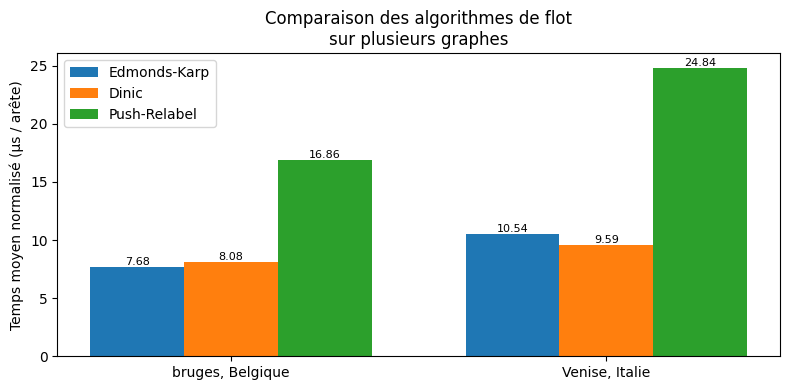

In [30]:
plot_results(result)

In [ ]:
# Affichage des performances
def print_performance(benchmark_results):
  """
  Affiche les performances normalisées de chaque algorithme par graphe.

  Args:
      benchmark_results: Dictionnaire des résultats produit par `build_graph`.
  """
  print("Performance Results:")
  for graph_name, algo_times in benchmark_results.items():
    print(f"\n--- {graph_name} ---")
    for algo_name, time_per_edge in algo_times.items():
      print(f"{algo_name:15s}: {time_per_edge:.2f} µs / edge")


In [ ]:
print_performance(result)

Performance Results:

--- Nimy, Belgique ---
Edmonds-Karp   : 13.67 µs / edge
Dinic          : 15.98 µs / edge
Push-Relabel   : 26.64 µs / edge

--- Gosselies, Belgique ---
Edmonds-Karp   : 10.03 µs / edge
Dinic          : 17.85 µs / edge
Push-Relabel   : 26.39 µs / edge

--- Obourg, Belgique ---
Edmonds-Karp   : 9.81 µs / edge
Dinic          : 18.76 µs / edge
Push-Relabel   : 23.64 µs / edge


In [ ]:
#Verifier que tous les algos retournent le même flot max
def check_results(results):
  """
  Affiche la valeur de flot calculée pour chaque algorithme.

  Args:
      results: Dictionnaire de résultats contenant une clé `flow_value` par algorithme.
  """
  for name, res in results.items():
      print(f"{name:20s} → flow = {res['flow_value']}")


#***Dynamic Flow : Edmonds-Karp, Dinic, Push-Relabel***

In [31]:
class DynamicEdmondsKarp_New:
    """
    Edmonds-Karp travaillant directement sur un graphe résiduel existant.
    Les flots déjà calculés sont conservés et réutilisés.
    """

    def __init__(self, G, source, sink, capacity_attr_name='capacity'):
        """
        Initialise l'algorithme avec un graphe résiduel, une source et un puits.

        Args:
            G: Graphe résiduel orienté avec flots et capacités déjà définis sur les arêtes.
            source: Nœud source.
            sink: Nœud puits.
            capacity_attr_name: Nom de l'attribut de capacité sur les arêtes.
        """
        self.G = G.copy()
        self.s = source
        self.t = sink
        self.capacity_attr_name = capacity_attr_name

        # On complète le graphe : on s'assure que les arêtes inverses existent
        # et que chaque arête a bien une capacité, SANS écraser les flots existants.
        for u_node, v_node, data in list(self.G.edges(data=True)):
            # Capacité par défaut si absente
            if self.capacity_attr_name not in data:
                data[self.capacity_attr_name] = 1

            # Flot par défaut à 0 uniquement si absent (on ne l'écrase pas)
            if 'flow' not in data:
                data['flow'] = 0

            # Création de l'arête inverse si elle n'existe pas encore
            if not self.G.has_edge(v_node, u_node):
                self.G.add_edge(v_node, u_node, **{self.capacity_attr_name: 0, 'flow': 0})

        # La valeur du flot courant est déduite du flot sortant de la source
        # (somme des flots positifs sur les arêtes partant de s).
        self.flow_value = sum(
            self.G[self.s][v].get('flow', 0)
            for v in self.G.neighbors(self.s)
            if self.G[self.s][v].get('flow', 0) > 0
        )

        # On continue Edmonds-Karp à partir du flot existant
        # sans repartir de zéro.
        self._edmonds_karp()

    def _bfs(self):
        """
        Cherche un chemin augmentant dans le graphe résiduel.

        Returns:
            Un dictionnaire des parents si un chemin existe, sinon None.
        """
        parent = {self.s: None}
        queue = deque([self.s])

        while queue:
            u = queue.popleft()
            for v in self.G.neighbors(u):
                residual_cap = self.G[u][v].get(self.capacity_attr_name, 0) - self.G[u][v].get('flow', 0)

                if v not in parent and residual_cap > 0:
                    parent[v] = u
                    if v == self.t:
                        return parent
                    queue.append(v)
        return None

    def _augment(self, parent):
        """
        Augmente le flot le long d'un chemin trouvé par BFS.

        Args:
            parent: Dictionnaire des parents décrivant le chemin augmentant.
        """
        path_flow = float('inf')
        v = self.t
        path = []

        while v != self.s:
            u = parent[v]
            path.append((u, v))
            residual_cap = self.G[u][v].get(self.capacity_attr_name, 0) - self.G[u][v].get('flow', 0)
            path_flow = min(path_flow, residual_cap)
            v = u
        path.reverse()

        for u_node, v_node in path:
            self.G[u_node][v_node]['flow'] += path_flow
            self.G[v_node][u_node]['flow'] -= path_flow

        self.flow_value += path_flow

    def _edmonds_karp(self):
        """Continue Edmonds-Karp jusqu'à saturation de tous les chemins augmentants."""
        while True:
            parent = self._bfs()
            if parent is None:
                break
            self._augment(parent)

    def get_max_flow(self):
        """Retourne la valeur actuelle du flot maximum calculé."""
        return self.flow_value

    def update_edge_capacity(self, u, v, new_capacity_value):
        """
        Met à jour la capacité d'une arête et ajuste le flot existant si nécessaire,
        puis continue Edmonds-Karp à partir du flot courant (sans tout remettre à zéro).

        Args:
            u: Nœud source de l'arête.
            v: Nœud cible de l'arête.
            new_capacity_value: Nouvelle capacité à affecter.
        """
        if not self.G.has_edge(u, v):
            self.G.add_edge(u, v, **{self.capacity_attr_name: new_capacity_value, 'flow': 0})
            if not self.G.has_edge(v, u):
                self.G.add_edge(v, u, **{self.capacity_attr_name: 0, 'flow': 0})
            self._edmonds_karp()
            return

        current_flow = self.G[u][v].get('flow', 0)
        old_capacity = self.G[u][v].get(self.capacity_attr_name, 0)

        self.G[u][v][self.capacity_attr_name] = new_capacity_value

        if new_capacity_value >= current_flow:
            # CAS 1 : flot courant toujours faisable, on cherche juste
            # de nouveaux chemins augmentants.
            self._edmonds_karp()

        else:
            # CAS 2 : le flot dépasse la nouvelle capacité → violation.
            # On retire l'excès localement et on rééquilibre.
            excess = current_flow - new_capacity_value

            self.G[u][v]['flow'] = new_capacity_value
            self.G[v][u]['flow'] -= excess

            # La valeur globale de flot diminue uniquement si (u,v)
            # est une arête directe (et non une rétro-arête résiduelle).
            if old_capacity > 0:
                self.flow_value -= excess

            self._edmonds_karp()

In [32]:
class IncrementalDinicFlow_new:
    """Wrapper autour de Dinic avec support d'une mise à jour de capacité sur le graphe résiduel."""

    def __init__(self, G, source, sink, capacity_attr_name='capacity'):
        """
        Initialise la structure incrémentale basée sur Dinic.

        Args:
            G: Graphe de départ.
            source: Nœud source.
            sink: Nœud puits.
            capacity_attr_name: Nom de l'attribut de capacité.
        """
        self.G_original = G.copy()
        self.source = source
        self.sink = sink
        self.capacity_attr_name = capacity_attr_name

        for u, v, data in self.G_original.edges(data=True):
            if 'flow' not in data:
                data['flow'] = 0

        self.residual_graph = nx.algorithms.flow.dinitz(
            self.G_original,
            self.source,
            self.sink,
            capacity=self.capacity_attr_name
        )

        self.flow_value = self.residual_graph.graph["flow_value"]

        #print(f"IncrementalDinicFlow initialized. Initial max flow: {self.flow_value}")

    def get_max_flow(self):
        """Retourne la valeur actuelle du flot maximum."""
        return self.flow_value

    def _res_cap(self, u, v) -> int:
        """
        Calcule la capacité résiduelle d'une arête.

        Args:
            u: Nœud source de l'arête.
            v: Nœud cible de l'arête.

        Returns:
            La capacité encore disponible sur l'arête dans le graphe résiduel.
        """
        if not self.residual_graph.has_edge(u, v):
            return 0
        d = self.residual_graph[u][v]
        return d[self.capacity_attr_name] - d["flow"]

    def _current_flow_value(self) -> int:
        """
        Recalcule la valeur de flot courante depuis les arêtes sortant de la source.

        Returns:
            La somme des flux positifs en sortie de la source.
        """
        return sum(
            d["flow"] for _, _, d in self.residual_graph.out_edges(self.source, data=True) if d["flow"] > 0
        )

    def _cancel_flow_on_path(self, path: list, amount: int):
        """
        Annule une quantité de flot le long d'un chemin donné.

        Args:
            path: Liste ordonnée de nœuds formant le chemin.
            amount: Quantité de flot à retirer.
        """
        for i in range(len(path) - 1):
            u, v = path[i], path[i + 1]
            self.residual_graph[u][v]["flow"] -= amount
            self.residual_graph[v][u]["flow"] += amount

    def _find_path_with_flow(self, start, end) -> tuple[list, int]:
        """
        Recherche un chemin portant déjà du flot positif entre deux nœuds.

        Args:
            start: Nœud de départ.
            end: Nœud d'arrivée.

        Returns:
            Un tuple `(chemin, bottleneck)` ou `([], 0)` si aucun chemin n'est trouvé.
        """
        prev: dict = {}
        visited = {start}
        q = deque([start])
        while q:
            u = q.popleft()
            if u == end:
                path = []
                node = end
                while node != start:
                    parent = prev[node]
                    path.append(node)
                    node = parent
                path.append(start)
                path.reverse()

                # Le bottleneck limite la quantité de flot que l'on peut annuler sur ce chemin.
                bottleneck = math.inf
                for i in range(len(path) - 1):
                    u_path, v_path = path[i], path[i + 1]
                    if "flow" in self.residual_graph[u_path][v_path]:
                        bottleneck = min(bottleneck, self.residual_graph[u_path][v_path]["flow"])
                    else:
                        bottleneck = 0
                        break
                if bottleneck == math.inf:
                    bottleneck = 0
                return path, bottleneck
            for v in self.residual_graph.successors(u):
                if v not in visited and self.residual_graph[u][v].get("flow", 0) > 0:
                    visited.add(v)
                    prev[v] = u
                    q.append(v)
        return [], 0

    def _cancel_excess(self, start, end, excess: int):
        """
        Annule progressivement un excès de flot entre deux nœuds.

        Args:
            start: Nœud de départ de l'annulation.
            end: Nœud d'arrivée de l'annulation.
            excess: Quantité de flot à annuler.
        """
        while excess > 0:
            path, bottleneck = self._find_path_with_flow(start, end)
            if not path or bottleneck == 0:
                break
            to_cancel = min(excess, bottleneck)
            self._cancel_flow_on_path(path, to_cancel)
            excess -= to_cancel

    def update_edge_capacity(self, u, v, new_cap: int):
        """
        Met à jour la capacité d'une arête et réutilise le résiduel lorsque c'est possible.

        Args:
            u: Nœud source de l'arête.
            v: Nœud cible de l'arête.
            new_cap: Nouvelle capacité à appliquer.
        """
        if not self.residual_graph.has_edge(u, v):
            raise ValueError(f"L'arête ({u}, {v}) n'existe pas dans le graphe résiduel.")

        current_flow_ab = self.residual_graph[u][v].get("flow", 0)
        excess = current_flow_ab - new_cap

        if excess <= 0:
            self.residual_graph[u][v][self.capacity_attr_name] = new_cap
            self.residual_graph = nx.algorithms.flow.dinitz(
                self.G_original,
                self.source,
                self.sink,
                capacity=self.capacity_attr_name,
                residual=self.residual_graph
            )
            self.flow_value = self.residual_graph.graph["flow_value"]
        else:
            # Si la nouvelle capacité viole le flot courant, on annule d'abord l'excès utilisable.
            self._cancel_excess(v, self.sink, excess)
            self._cancel_excess(self.source, u, excess)

            self.residual_graph[u][v][self.capacity_attr_name] = new_cap
            self.residual_graph[u][v]["flow"] = new_cap
            if not self.residual_graph.has_edge(v, u):
                self.residual_graph.add_edge(v, u, **{self.capacity_attr_name: 0, 'flow': 0})
            self.residual_graph[v][u]["flow"] = -new_cap

            self.flow_value = self._current_flow_value()

            self.residual_graph = nx.algorithms.flow.dinitz(
                self.G_original,
                self.source,
                self.sink,
                capacity=self.capacity_attr_name,
                residual=self.residual_graph
            )
            self.flow_value = self.residual_graph.graph["flow_value"]


In [33]:
class IncrementalPreflowPushFlow_New:
    """
    Wrapper autour de Preflow-Push avec mise à jour dynamique de capacité.

    Contrairement à la version Dinic, on exploite le fait que Preflow-Push
    accepte nativement des sommets en excès de flot : au lieu de chercher des
    chemins pour "réparer" manuellement le flot, on crée simplement l'excès
    sur le nœud concerné et on laisse l'algorithme le résorber.

    Labels valides après réduction de capacité
    ------------------------------------------
    Si on réduit cap(u,v) et que flow(u,v) > new_cap, on retire delta = flow - new_cap
    unités de flot de l'arête (u,v).  Cela crée un excès en u  (source locale du
    flot retiré) et un déficit en v.  La condition de validité des labels,
    label(u) <= label(v) + 1, reste satisfaite puisqu'on *supprime* du flot sur
    (u,v) : on n'envoie rien dans le sens interdit.  Preflow-Push peut donc
    repartir directement sur ce résiduel.
    """

    def __init__(self, G, source, sink, capacity_attr_name='capacity'):
        """
        Calcule le flot initial (hors chronométrage dynamique).

        Args:
            G: Graphe de départ.
            source: Nœud source.
            sink: Nœud puits.
            capacity_attr_name: Nom de l'attribut de capacité.
        """
        self.source = source
        self.sink = sink
        self.capacity_attr_name = capacity_attr_name

        G_init = G.copy()
        for u, v, data in G_init.edges(data=True):
            if 'flow' not in data:
                data['flow'] = 0

        # Calcul du flot initial — ne fait pas partir du temps dynamique mesuré.
        self.residual_graph = nx.algorithms.flow.preflow_push(
            G_init,
            self.source,
            self.sink,
            capacity=self.capacity_attr_name,
        )
        self.flow_value = self.residual_graph.graph["flow_value"]

    def get_max_flow(self):
        """Retourne la valeur actuelle du flot maximum."""
        return self.flow_value

    def _res_cap(self, u, v) -> int:
        """Capacité résiduelle de l'arête (u, v)."""
        if not self.residual_graph.has_edge(u, v):
            return 0
        d = self.residual_graph[u][v]
        return d[self.capacity_attr_name] - d["flow"]

    def _current_flow_value(self) -> int:
        """Flot courant mesuré en sortie de la source."""
        return sum(
            d["flow"]
            for _, _, d in self.residual_graph.out_edges(self.source, data=True)
            if d["flow"] > 0
        )

    def update_edge_capacity(self, u, v, new_cap: int):
        """
        Met à jour la capacité de (u,v) et recalcule le flot maximum.

        Cas 1 — augmentation ou pas de dépassement (new_cap >= flow(u,v)) :
            On met à jour la capacité dans le résiduel et on relance
            Preflow-Push ; l'excès éventuel sur d'autres nœuds est géré
            nativement par l'algorithme.

        Cas 2 — réduction sous le flot courant (new_cap < flow(u,v)) :
            delta = flow(u,v) - new_cap unités de flot deviennent invalides.
            On retire delta directement sur l'arête dans le résiduel (flow -= delta,
            reverse flow += delta).  Cela place u en excès de delta : Preflow-Push
            le résorbe sans qu'on ait à chercher des chemins manuellement.
            Les labels restent valides car on ne pousse rien dans un sens
            interdit.

        Seule cette méthode est chronométrée dans le benchmark dynamique.

        Args:
            u: Nœud source de l'arête.
            v: Nœud cible de l'arête.
            new_cap: Nouvelle capacité à appliquer.
        """
        if not self.residual_graph.has_edge(u, v):
            raise ValueError(f"L'arête ({u}, {v}) n'existe pas dans le graphe résiduel.")

        current_flow_uv = self.residual_graph[u][v].get("flow", 0)
        delta = current_flow_uv - new_cap  # > 0 ssi on dépasse la nouvelle capacité

        if delta > 0:
            # Retrait direct de delta sur l'arête : u se retrouve en excès,
            # ce que Preflow-Push sait gérer nativement.
            self.residual_graph[u][v]["flow"] -= delta
            self.residual_graph[u][v][self.capacity_attr_name] = new_cap

            # Arête inverse : on rend delta disponible dans l'autre sens.
            if not self.residual_graph.has_edge(v, u):
                self.residual_graph.add_edge(v, u, **{self.capacity_attr_name: 0, "flow": 0})
            self.residual_graph[v][u]["flow"] -= delta  # capacité résiduelle v->u diminue
        else:
            # Cas simple : on augmente (ou maintient) la capacité.
            self.residual_graph[u][v][self.capacity_attr_name] = new_cap

        # Preflow-Push repart du résiduel modifié ; l'excès éventuel en u
        # est résorbé par l'algorithme sans intervention manuelle.
        self.residual_graph = nx.algorithms.flow.preflow_push(
            self.residual_graph,          # graphe résiduel = point de départ
            self.source,
            self.sink,
            capacity=self.capacity_attr_name,
            residual=self.residual_graph,
        )
        self.flow_value = self.residual_graph.graph["flow_value"]


# **Compute bridges and select one of them**

In [34]:
def search_bridges(graph_dict):
  """
  Sélectionne un pont aléatoire dans chaque graphe.

  Args:
      graph_dict: Dictionnaire de graphes simples par lieu.

  Returns:
      Un dictionnaire associant chaque lieu à une arête qui est un pont.
  """
  result = {}
  for place, graph in graph_dict.items():
    bridges = list(nx.bridges(graph))
    random.shuffle(bridges)
    selected_bridge = random.choice(bridges)
    result[place] = selected_bridge
  return result


In [35]:
def search_bridges(graph_dict):
  """
  Sélectionne un pont aléatoire dans chaque graphe.

  Args:
      graph_dict: Dictionnaire de graphes simples par lieu.

  Returns:
      Un dictionnaire associant chaque lieu à une arête qui est un pont.
      Retourne None pour une ville si aucun pont n'est trouvé.
  """
  result = {}
  for place, graph in graph_dict.items():
    bridges = list(nx.bridges(graph))
    if not bridges:  # Check if the list of bridges is empty
      result[place] = None  # Assign None if no bridges are found
      print(f"Warning: No bridges found for {place}. No bridge selected for this graph.")
    else:
      random.shuffle(bridges)
      selected_bridge = random.choice(bridges)
      result[place] = selected_bridge
  return result

selected_bridges = search_bridges(add_capacity)
selected_bridges

{'bruges, Belgique': (322609352, 1082516931),
 'Venise, Italie': (2290254422, 3625543566)}

In [41]:
def select_random_edge(graph):
  """
  Sélectionne une arête aléatoire dans un graphe.

  Args:
      graph: Graphe simple.

  Returns:
      Un tuple
  """
  result = {}
  for place, graph in graph.items():
    edges = list(graph.edges())
    random.shuffle(edges)
    selected_edge = random.choice(edges)
    result[place] = selected_edge
  return result

In [42]:
selected_random_edges = select_random_edge(add_capacity)
selected_random_edges

{'bruges, Belgique': (271927355, 312709479),
 'Venise, Italie': (29985887, 34088743)}

# **Run dynamics algorithms and plot histogram of the mofied graph**

In [36]:
def get_dynamic_graphs(graphs_dict):
    """
    Associe à chaque graphe dynamique son couple source/puits.

    Args:
        graphs_dict: Dictionnaire de graphes par lieu.

    Returns:
        Un dictionnaire `{lieu: (graphe, source, sink)}` pour les benchmarks dynamiques.
    """
    all_graphs = {}
    #souce_sink = get_nodes_sorted_by_degree(graphs_dict) just for maximum degree method
    for place, graph in graphs_dict.items():
      source, sink = result_source_sink[place]
      #source, sink = list(souce_sink[place].keys())[0] just for maximum degree method
      all_graphs[place] = (graph, source, sink)
      if nx.has_path(graph, source, sink):
        pass
      else:
        print("no path exist")
    return all_graphs

algos = {
    "Edmonds-Karp": DynamicEdmondsKarp_New,
    "Dinic": IncrementalDinicFlow_new,
    "Push-Relabel": IncrementalPreflowPushFlow_New
}


In [37]:
dynamic_graphs = get_dynamic_graphs(add_capacity)
dynamic_graphs

{'bruges, Belgique': (<networkx.classes.graph.Graph at 0x79ba37392b40>,
  3390812463,
  82732110),
 'Venise, Italie': (<networkx.classes.graph.Graph at 0x79ba249a6030>,
  986220039,
  1100588297)}

In [38]:
def benchmark_maxflow_dynamic(G_original, s, t, AlgoClass, runs=5, modified_edge=None):
    """
    Mesure le coût de la mise à jour dynamique d'un algorithme de flot max.

    L'initialisation (calcul du flot initial) est effectuée HORS chronométrage
    pour tous les algorithmes : seul le coût de update_edge_capacity() est mesuré.
    Si modified_edge est None, on mesure le coût d'initialisation seul (cas de
    référence, pas de mise à jour).

    ===== gc.collect()=====
    NetworkX crée beaucoup d'objets Python
    temporaires (dicts de flot, structures internes).
    Sans collecte forcée, le ramasse-miettes peut se déclencher
    pendant la mesure time.perf_counter(),
    introduisant un pic de latence imprévisible qui fausse les temps.
    En forçant la collecte avant de démarrer,
    on s'assure que la GC ne viendra pas interrompre le run chronométré.

    Args:
        G_original: Graphe original copié à chaque exécution.
        s: Nœud source.
        t: Nœud puits.
        AlgoClass: Classe implémentant l'algorithme dynamique.
        runs: Nombre de répétitions pour la mesure.
        modified_edge: Tuple optionnel `(u, v, new_capacity)`.

    Returns:
        Dictionnaire {"flow_value": int, "mean_time": float}.
    """
    times = []
    flow_value = None

    if modified_edge is None:
        # Mesure de l'initialisation seule (flot initial).
        for _ in range(runs):
            #gc.collect()
            G_copy = G_original.copy()
            #start = time.perf_counter()
            algo_instance = AlgoClass(G_copy, s, t, capacity_attr_name="capacity")
            flow_value = algo_instance.get_max_flow()
            #end = time.perf_counter()
            #times.append(end - start)
    else:
        u, v, new_capacity = modified_edge

        if not G_original.has_edge(u, v) and not G_original.has_edge(v, u):
            raise ValueError(f"Edge ({u}, {v}) not found in graph for dynamic update benchmark.")

        for _ in range(runs):
            # Force la collecte des objets cycliques avant chaque run
            # pour éviter qu'un déclenchement du GC pendant le chronomètre
            # ne fausse la mesure de temps.
            gc.collect()
            G_copy = G_original.copy()

            # ── Initialisation hors chrono ──────────────────────────────────
            # Le but de l'algo dynamique est d'être rapide pour la mise à
            # jour, pas pour le calcul initial.  On initialise donc avant de
            # démarrer le chronomètre.
            algo_instance = AlgoClass(G_copy, s, t, capacity_attr_name="capacity")

            # ── Seule la mise à jour est chronométrée ───────────────────────
            start = time.perf_counter()
            algo_instance.update_edge_capacity(u, v, new_capacity)
            flow_value = algo_instance.get_max_flow()
            end = time.perf_counter()
            times.append(end - start)

    return {
        "flow_value": flow_value,
        "mean_time": sum(times) / runs,
    }


In [39]:
def build_dynamic_graph(graphs_dict, graphs_dict_original, list_capacity):
    """
    Lance les benchmarks des variantes dynamiques de flot maximum.

    Tous les algorithmes sont évalués avec modified_edge renseigné : seule la
    phase de mise à jour (update_edge_capacity) est chronométrée, conformément
    à l'objectif des algorithmes dynamiques.

    Args:
        graphs_dict: Dictionnaire `{lieu: (graphe, source, sink)}`.
        graphs_dict_original: Dictionnaire de graphes d'origine.
        list_capacity: Liste des nouvelles capacités à tester pour chaque graphe.

    Returns:
        Dictionnaire des temps moyens normalisés par graphe et par algorithme.
    """
    all_results = {}
    graph_only_dict = {gname: G for gname, (G, s, t) in graphs_dict.items()}
    bridges_dict = select_random_edge(graph_only_dict)

    if len(list_capacity) != len(graphs_dict):
        raise ValueError("list_capacity doit avoir autant d'entrées que de graphes.")

    for i, (item_dyn, item_orig) in enumerate(
        zip(graphs_dict.items(), graphs_dict_original.items())
    ):
        place, (G_dyn, s, t) = item_dyn
        _, G_orig_entry = item_orig          # G_orig_entry peut être un graphe ou un dict

        num_edges = G_dyn.number_of_edges()
        u, v = bridges_dict[place]
        new_cap = list_capacity[i]

        all_results[place] = {}

        for aname, AlgoClass in algos.items():
            # Edmonds-Karp dispose d'un graphe résiduel pré-calculé séparé.
            if aname == "Edmonds-Karp":
                G_for_bench = G_orig_entry["Edmonds-Karp"]
            else:
                G_for_bench = G_dyn

            res = benchmark_maxflow_dynamic(
                G_for_bench, s, t, AlgoClass,
                runs=7,
                modified_edge=(u, v, new_cap),   # ← tous les algos passent ici
            )
            # Normalisation en µs / arête pour la lisibilité.
            all_results[place][aname] = (res["mean_time"] / num_edges) * 1e6

    return all_results


In [ ]:
for i, d in enumerate(zip(dynamic_graphs.items(), add_capacity.items())):
    print(d[0][1])

(<networkx.classes.graph.Graph object at 0x7c4adbdeeb70>, 715553013, 462714989)
(<networkx.classes.graph.Graph object at 0x7c4ae0bc09b0>, 5814693474, 829531519)
(<networkx.classes.graph.Graph object at 0x7c4adbdee6f0>, 4171742276, 1069566135)


In [ ]:
d = {'e':7, 'r':8, 't':6, 'a':9}
g = {'g':7, 'm':0, 'd':4, 'v':95}
for i, d in enumerate(zip(d.items(),g.items())):
  print(i,d)


0 (('e', 7), ('g', 7))
1 (('r', 8), ('m', 0))
2 (('t', 6), ('d', 4))
3 (('a', 9), ('v', 95))


In [44]:
cap  = [20,20]
build_dynamic_graph(dynamic_graphs,residual, cap)

{'bruges, Belgique': {'Edmonds-Karp': 0.020820756859126308,
  'Dinic': 2.013983822139467,
  'Push-Relabel': 12.814849797023022},
 'Venise, Italie': {'Edmonds-Karp': 0.011613196010251748,
  'Dinic': 3.2609513527078096,
  'Push-Relabel': 51.229979604539054}}

In [45]:
#Plot results
def plot_dynamic_results(all_results):
    """
    Trace un histogramme des performances des algorithmes dynamiques de flot.

    Args:
        all_results: Dictionnaire des performances par graphe et par algorithme.
    """
    graph_names = list(all_results.keys())
    algo_names = list(algos.keys())

    x = np.arange(len(graph_names))
    width = 0.25

    plt.figure(figsize=(8, 4))

    for i, algo in enumerate(algo_names):
        values = [all_results[g][algo] for g in graph_names]
        bars = plt.bar(x + i * width, values, width, label=algo)

        for bar, val in zip(bars, values):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    plt.xticks(x + width, graph_names)
    plt.ylabel("Temps moyen normalisé (µs / arête)")
    plt.title("Comparaison des algorithmes dynamiques de flot\nsur plusieurs graphes")
    plt.legend()
    plt.tight_layout()
    plt.show()


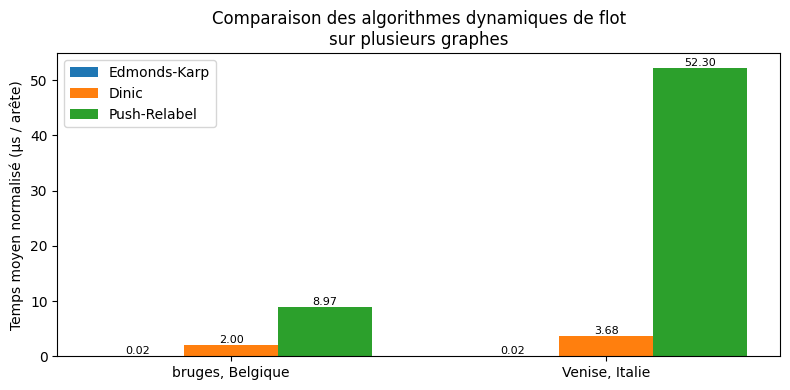

In [46]:
plot_dynamic_results(build_dynamic_graph(dynamic_graphs,residual,cap))

In [ ]:
# Affichage des performances
def print_performance(all_results):
  """
  Recalcule et retourne les benchmarks de flot pour chaque graphe.

  Args:
      all_results: Paramètre conservé pour compatibilité avec l'appel existant.

  Returns:
      Une liste de tuples `(nom_du_graphe, résultats_des_algorithmes)`.
  """
  results = {}
  res = []
  for names, graph in get_graphs(add_capacity).items():
    for name, algo in algos.items():
      G, source, sink = graph
      results[name] = benchmark_maxflow(G, source, sink, algo, runs=7)
    res.append((names, results))
  return res


In [ ]:
dynamic_results = build_dynamic_graph(dynamic_graphs, residual, cap)

print("Performance Results (Dynamic):")
for graph_name, algo_times in dynamic_results.items():
  print(f"\n--- {graph_name} ---")
  for algo_name, time_per_edge in algo_times.items():
    print(f"{algo_name:15s}: {time_per_edge:.2f} \u00B5s / edge")

IncrementalDinicFlow initialized. Initial max flow: 12240.0
IncrementalDinicFlow initialized. Initial max flow: 12240.0
IncrementalDinicFlow initialized. Initial max flow: 12240.0
IncrementalDinicFlow initialized. Initial max flow: 12240.0
IncrementalDinicFlow initialized. Initial max flow: 12240.0
IncrementalDinicFlow initialized. Initial max flow: 12240.0
IncrementalDinicFlow initialized. Initial max flow: 12240.0
IncrementalDinicFlow initialized. Initial max flow: 11880.0
IncrementalDinicFlow initialized. Initial max flow: 11880.0
IncrementalDinicFlow initialized. Initial max flow: 11880.0
IncrementalDinicFlow initialized. Initial max flow: 11880.0
IncrementalDinicFlow initialized. Initial max flow: 11880.0
IncrementalDinicFlow initialized. Initial max flow: 11880.0
IncrementalDinicFlow initialized. Initial max flow: 11880.0
IncrementalDinicFlow initialized. Initial max flow: 10440.0
IncrementalDinicFlow initialized. Initial max flow: 10440.0
IncrementalDinicFlow initialized. Initia

# **test**